In [4]:
import torch
import tensorflow as tf
import jax
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# y = m * X + b 
# y = 3X + 5

Text(0.5, 0, 'x')

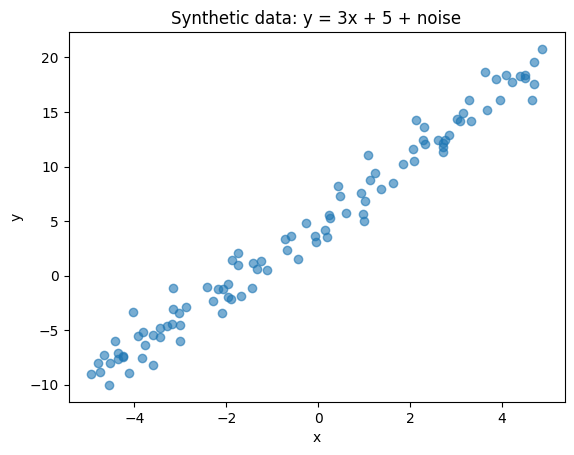

In [10]:
np.random.seed(42)
TRUE_W = 3.0
TRUE_B = 5.0

N = 100

x_data = np.random.uniform(-5,5, size=(N,1)).astype(np.float32)
noise = np.random.normal(0, 1.5, size=(N,1)).astype(np.float32)
y_data = (TRUE_W * x_data + TRUE_B + noise).astype(np.float32)

plt.scatter(x_data, y_data, alpha=0.6)
plt.title("Synthetic data: y = 3x + 5 + noise")
plt.ylabel("y")
plt.xlabel("x")

In [9]:
# d(loss)/d(w) and d(loss)/d(b)

100

In [15]:
def train(lr, epochs=200):
    torch.manual_seed(42)
    x_t = torch.from_numpy(x_data)
    y_t = torch.from_numpy(y_data)


    w = torch.rand(1, requires_grad=True)
    b = torch.rand(1, requires_grad=True)

    for epoch in range(epochs):
        y_pred = x_t * w + b
        loss = ((y_pred - y_t)**2).mean()
        loss.backward()
        with torch.no_grad():
            w -= lr * w.grad
            b -= lr * b.grad
            w.grad.zero_()
            b.grad.zero_()
        if epoch % 40 ==0:
            if epoch % 40 == 0:
                print(f"epoch {epoch:3d} | loss/mse {loss.item():.4f} | w {w.item():.3f} | b {b.item():.3f}")

    print(f"\nFinal -> w: {w.item():.3f}, b: {b.item():.3f}  (true: w={TRUE_W}, b={TRUE_B})")

train(0.1, epochs=200)
train(0.01, epochs=200)
train(0.001, epochs=200)

epoch   0 | loss/mse 50.5061 | w 1.221 | b 0.984
epoch  40 | loss/mse 5.2397 | w 2.861 | b 3.155
epoch  80 | loss/mse 2.5078 | w 2.900 | b 4.158
epoch 120 | loss/mse 1.9551 | w 2.917 | b 4.609
epoch 160 | loss/mse 1.8432 | w 2.925 | b 4.812

Final -> w: 2.928, b: 4.902  (true: w=3.0, b=5.0)


In [16]:
torch.manual_seed(42)
x_t = torch.from_numpy(x_data)
y_t = torch.from_numpy(y_data)
w = torch.rand(1, requires_grad=True)
b = torch.rand(1, requires_grad=True)

optimizer = torch.optim.SGD([w,b], lr=0.01)
epochs = 200

for epoch in range(epochs):
    y_pred = x_t * w + b
    loss = ((y_pred - y_t)**2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 40 ==0:
        print(f"epoch {epoch:3d} | loss/mse {loss.item():.4f} | w {w.item():.3f} | b {b.item():.3f}")

print(f"\nFinal -> w: {w.item():.3f}, b: {b.item():.3f}  (true: w={TRUE_W}, b={TRUE_B})")

epoch   0 | loss/mse 50.5061 | w 1.221 | b 0.984
epoch  40 | loss/mse 5.2397 | w 2.861 | b 3.155
epoch  80 | loss/mse 2.5078 | w 2.900 | b 4.158
epoch 120 | loss/mse 1.9551 | w 2.917 | b 4.609
epoch 160 | loss/mse 1.8432 | w 2.925 | b 4.812

Final -> w: 2.928, b: 4.902  (true: w=3.0, b=5.0)


In [17]:
torch.manual_seed(42)
x_t = torch.from_numpy(x_data)
y_t = torch.from_numpy(y_data)
w = torch.rand(1, requires_grad=True)
b = torch.rand(1, requires_grad=True)

optimizer = torch.optim.Adam([w,b], lr=0.01)
epochs = 200

for epoch in range(epochs):
    y_pred = x_t * w + b
    loss = ((y_pred - y_t)**2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 40 ==0:
        print(f"epoch {epoch:3d} | loss/mse {loss.item():.4f} | w {w.item():.3f} | b {b.item():.3f}")

print(f"\nFinal -> w: {w.item():.3f}, b: {b.item():.3f}  (true: w={TRUE_W}, b={TRUE_B})")

epoch   0 | loss/mse 50.5061 | w 0.892 | b 0.925
epoch  40 | loss/mse 35.9576 | w 1.283 | b 1.321
epoch  80 | loss/mse 25.1386 | w 1.633 | b 1.703
epoch 120 | loss/mse 17.5048 | w 1.935 | b 2.066
epoch 160 | loss/mse 12.2943 | w 2.186 | b 2.409

Final -> w: 2.383, b: 2.723  (true: w=3.0, b=5.0)


In [18]:
def train_and_record(optimizer_name="manual", lr=0.01, epochs=200):
    """Trains y = w*x + b on x_data/y_data and returns the loss recorded every epoch.

    optimizer_name: "manual" (raw gradient descent), "sgd", or "adam"
    """
    torch.manual_seed(42)
    x_t = torch.from_numpy(x_data)
    y_t = torch.from_numpy(y_data)

    w = torch.randn(1, requires_grad=True)
    b = torch.randn(1, requires_grad=True)

    if optimizer_name == "sgd":
        optimizer = torch.optim.SGD([w, b], lr=lr)
    elif optimizer_name == "adam":
        optimizer = torch.optim.Adam([w, b], lr=lr)
    else:
        optimizer = None  # manual updates, no optimizer object

    losses = []
    for epoch in range(epochs):
        y_pred = x_t * w + b
        loss = ((y_pred - y_t) ** 2).mean()

        if optimizer is not None:
            optimizer.zero_grad() 
#             resets the gradients back to zero for every parameter 
#             the optimizer is tracking, 
#             clearing out whatever gradient values were left over 
#             from the previous training step.

#             PyTorch tensors accumulate gradients by default — 
#             every call to .backward() adds the newly 
#             computed gradient onto whatever is already stored 
#                 in .grad, rather than replacing it:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        else:
            loss.backward()
            with torch.no_grad():
                w -= lr * w.grad
                b -= lr * b.grad
                w.grad.zero_()
                b.grad.zero_()

        losses.append(loss.item())

    return losses, w.item(), b.item()


# --- Part 1: compare learning rates (manual gradient descent) ---
lr_runs = {}
for lr_value in [0.1, 0.01, 0.0001]:
    losses, w_final, b_final = train_and_record(optimizer_name="manual", lr=lr_value)
    lr_runs[lr_value] = losses
    print(f"lr={lr_value:<8} final loss={losses[-1]:.4f} | w={w_final:.3f} | b={b_final:.3f}")

# --- Parts 2 & 3: compare optimizers at a fixed learning rate ---
optimizer_runs = {}
for opt_name in ["manual", "sgd", "adam"]:
    losses, w_final, b_final = train_and_record(optimizer_name=opt_name, lr=0.01)
    optimizer_runs[opt_name] = losses
    print(f"optimizer={opt_name:<8} final loss={losses[-1]:.4f} | w={w_final:.3f} | b={b_final:.3f}")


lr=0.1      final loss=1.8148 | w=2.931 | b=4.978
lr=0.01     final loss=1.8233 | w=2.928 | b=4.887
lr=0.0001   final loss=49.5292 | w=1.063 | b=0.293
optimizer=manual   final loss=1.8233 | w=2.928 | b=4.887
optimizer=sgd      final loss=1.8233 | w=2.928 | b=4.887
optimizer=adam     final loss=17.6603 | w=1.956 | b=1.971


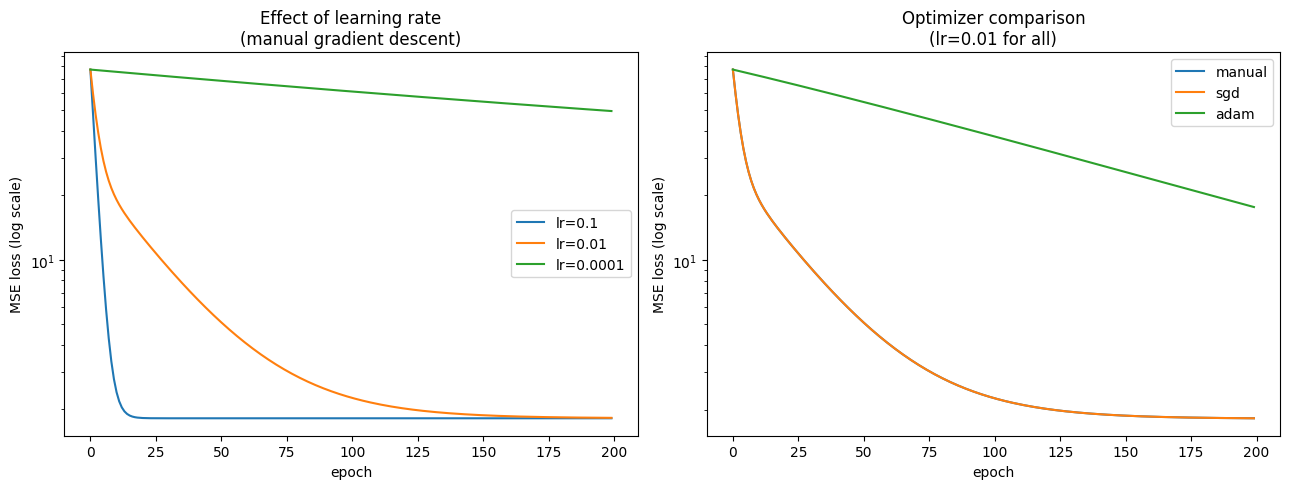

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: effect of learning rate (manual gradient descent)
ax = axes[0]
for lr_value, losses in lr_runs.items():
    ax.plot(losses, label=f"lr={lr_value}")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss (log scale)")
ax.set_title("Effect of learning rate\n(manual gradient descent)")
ax.legend()

# Right plot: manual vs SGD vs Adam, same lr
ax = axes[1]
for opt_name, losses in optimizer_runs.items():
    ax.plot(losses, label=opt_name)
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("MSE loss (log scale)")
ax.set_title("Optimizer comparison\n(lr=0.01 for all)")
ax.legend()

plt.tight_layout()
plt.show()

In [21]:
tf.random.set_seed(42)
x_tf = tf.constant(x_data)
y_tf = tf.constant(y_data)

w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))

lr = 0.01
epochs = 200

for epoch in range(epochs):
    with tf.GradientTape() as tape:
        y_pred = x_tf * w + b
        loss = tf.reduce_mean(tf.square(y_pred-y_tf))
        dw, db = tape.gradient(loss, [w,b])
        w.assign_sub(lr * dw)
        b.assign_sub(lr * db)
        if epoch % 40 ==0:
            print(f"epoch {epoch:3d} | loss {loss.numpy():.4f} | w {w.numpy()[0]:.3f} | b {b.numpy()[0]:.3f}")

print(f"\nFinal -> w: {w.numpy()[0]:.3f}, b: {b.numpy()[0]:.3f}  (true: w={TRUE_W}, b={TRUE_B})")

            

epoch   0 | loss 78.1566 | w 0.759 | b 0.167
epoch  40 | loss 6.7939 | w 2.847 | b 2.780
epoch  80 | loss 2.8223 | w 2.894 | b 3.989
epoch 120 | loss 2.0187 | w 2.914 | b 4.533
epoch 160 | loss 1.8561 | w 2.923 | b 4.778

Final -> w: 2.928, b: 4.886  (true: w=3.0, b=5.0)


In [23]:
with tf.GradientTape(persistent=True) as tape:
    y_pred = x_tf * w + b
    loss = tf.reduce_mean(tf.square(y_pred - y_tf))

dw = tape.gradient(loss, w)   # works
db = tape.gradient(loss, b)   # also works now

del tape

In [56]:
tf.random.set_seed(42)

x_tf = tf.constant(x_data)
y_tf = tf.constant(y_data)

# Parameters as tf.Variable — mutable state that TensorFlow tracks
w = tf.Variable(tf.random.normal([1]))
b = tf.Variable(tf.random.normal([1]))

lr = 0.01
epochs = 200

for epoch in range(epochs):
    # Everything inside the tape's context is recorded for differentiation
    with tf.GradientTape() as tape:
        y_pred = x_tf * w + b
        loss = tf.reduce_mean(tf.square(y_pred - y_tf))

    # Ask the tape for d(loss)/d(w) and d(loss)/d(b), in one call
    dw, db = tape.gradient(loss, [w, b])

    # Manual update, same idea as PyTorch's no_grad() block
    w.assign_sub(lr * dw)   # assign_sub = "assign w = w - lr*dw"
    b.assign_sub(lr * db)

    if epoch % 40 == 0:
        print(f"epoch {epoch:3d} | loss {loss.numpy():.4f} | w {w.numpy()[0]:.3f} | b {b.numpy()[0]:.3f}")

print(f"\nFinal -> w: {w.numpy()[0]:.3f}, b: {b.numpy()[0]:.3f}  (true: w={TRUE_W}, b={TRUE_B})")
del tape

predictions = x_tf * w + b

print(" predictions",predictions[:5].numpy().flatten())
print("actual", y_data[:5].flatten())

new_x = tf.constant([[0.0], [1.0],[10.0]])

new_predictions = new_x * w + b

# MSE
final_loss = tf.reduce_mean(tf.square(predictions-y_tf))
print("MSE",final_loss.numpy())

# R
y_true = y_data.flatten()
y_pred_np = predictions.numpy().flatten()
ss_res = np.sum((y_true - y_pred_np)**2)
ss_tot = np.sum((y_true - y_true.mean())**2)
r2 = 1 -(ss_res / ss_tot)
print("Scorer",r2)

epoch   0 | loss 78.1566 | w 0.759 | b 0.167
epoch  40 | loss 6.7939 | w 2.847 | b 2.780
epoch  80 | loss 2.8223 | w 2.894 | b 3.989
epoch 120 | loss 2.0187 | w 2.914 | b 4.533
epoch 160 | loss 1.8561 | w 2.923 | b 4.778

Final -> w: 2.928, b: 4.886  (true: w=3.0, b=5.0)
 predictions [ 1.2130897 18.080885  11.677734   7.7742705 -5.184239 ]
actual [ 1.3667741 18.072918  12.097459   4.978401  -5.6489487]
MSE 1.8231627
Scorer 0.9763485100120306


Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 39.6834 
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 24.7300 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.3204
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 16.3994 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.2286
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.4008
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.8209 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 9.4572  
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.2870
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.2882 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4385
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.7175
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.1066 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.5897
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.1527 
Epoch 16/200
4/4 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8835
Epoch 84/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8836
Epoch 85/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8837 
Epoch 86/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8838
Epoch 87/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8839
Epoch 88/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8840 
Epoch 89/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8841 
Epoch 90/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8842
Epoch 91/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8842
Epoch 92/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8843
Epoch 93/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8844 
Epoch 94/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8844 
Epoch 95/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.8845
Epoch 96/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8845 
Epoch 97/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8846 
Epoch 98/200
4/4 ━━━━━━━━━━━━━━

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8851
Epoch 165/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8851
Epoch 166/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8851
Epoch 167/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8851
Epoch 168/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8851 
Epoch 169/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8851
Epoch 170/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8851
Epoch 171/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8851 
Epoch 172/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.8851 
Epoch 173/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8851
Epoch 174/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8851
Epoch 175/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8851 
Epoch 176/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8851
Epoch 177/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8851 
Epoch 178/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8851 
Epoch 179/200
4/4 

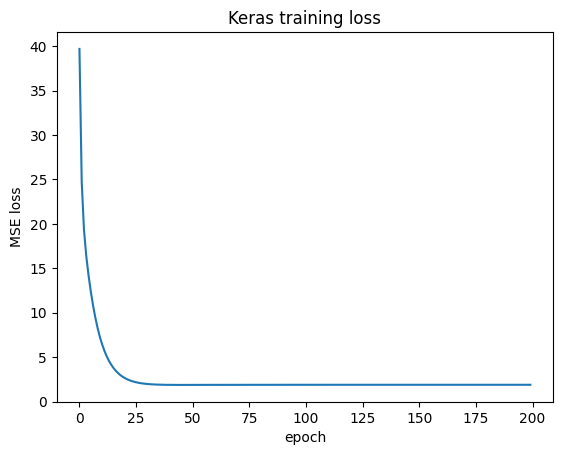

In [63]:
from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(42)

model = keras.Sequential([layers.Dense(1, input_shape=(1,))])
model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01), loss="mse")
history = model.fit(x_data, y_data, epochs=200)
w_learned, b_learned = model.layers[0].get_weights()
print(f"Final w {w_learned[0][0]:.3f}, b {b_learned[0]:.3f}")
plt.plot(history.history["loss"])
plt.title("Keras training loss")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.show()

In [65]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [66]:
loss = model.evaluate(x_data, y_data)
loss

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8964 


1.8963714838027954

In [67]:
predictions = model.predict(x_data, verbose=0).flatten()
y_true = y_data.flatten()
# flatten() converts multi-dimensional arrays (like matrices or batches of outputs) into a 1D vector (a single flat list of numbers).
ss_res = np.sum((y_true - predictions) ** 2)        # residual sum of squares
ss_tot = np.sum((y_true - y_true.mean()) ** 2)      # total variance in the data
r2 = 1 - (ss_res / ss_tot)

print(f"R² score: {r2:.4f}")

R² score: 0.9754


In [75]:
def train_keras_model(optimizer, epochs=200):
    keras.utils.set_random_seed(42)  # same seed -> same starting w, b for a fair comparison

    model = keras.Sequential([
        layers.Dense(1, input_shape=(1,))
    ])
    model.compile(optimizer=optimizer, loss="mse")
    early_stop = keras.callbacks.EarlyStopping(
        monitor = "loss",       # watch the training loss
        patience = 10,          # stop if no improvement for 10 straight epochs
        restore_best_weights = True   # roll back to the best epoch's weights, not the last one
    )

    history = model.fit(x_data, y_data, epochs=epochs, callbacks=[early_stop], verbose=0)
    return history.history["loss"], model

In [89]:
sgd_losses, sgd_model = train_keras_model(keras.optimizers.SGD(learning_rate=0.01))

In [90]:
len(sgd_losses)

57

In [91]:
adam_losses, adam_model = train_keras_model(keras.optimizers.Adam(learning_rate=0.1))

In [92]:
len(adam_losses)

29

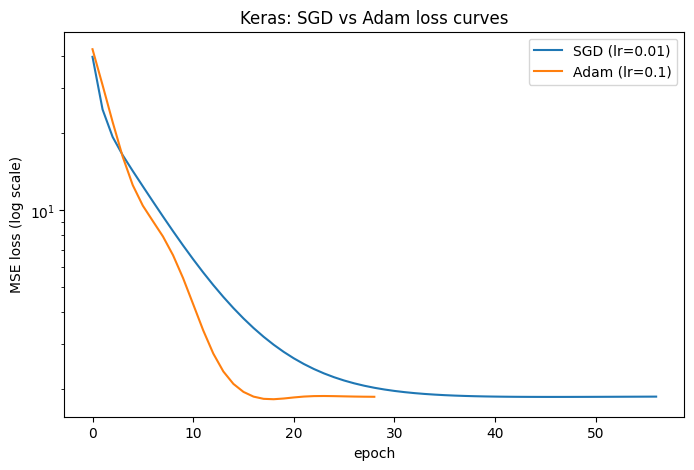

In [93]:
plt.figure(figsize=(8, 5))
plt.plot(sgd_losses, label="SGD (lr=0.01)")
plt.plot(adam_losses, label="Adam (lr=0.1)")
plt.yscale("log")   # log scale makes the shape differences easier to see
plt.xlabel("epoch")
plt.ylabel("MSE loss (log scale)")
plt.title("Keras: SGD vs Adam loss curves")
plt.legend()
plt.show()

In [114]:
import jax
import jax.numpy as jnp

x_jax = jnp.array(x_data)
y_jax = jnp.array(y_data)

# the forward pass
def predict(params, x):
    w, b = params
    return x * w + b

def loss_fn(params, x,y):
    preds = predict(params,x)
    return jnp.mean((preds-y)**2)

grad_fn = jax.jit(jax.grad(loss_fn))

key = jax.random.PRNGKey(42)
w_key, b_key = jax.random.split(key)
w_key

params = (jax.random.normal(w_key, (1,)), jax.random.normal(b_key, (1,)))

lr = 0.01
epochs = 200

for epoch in range(epochs):
    grads = grad_fn(params, x_jax,y_jax)
    params = tuple(p - lr * g for p, g in zip(params,grads))
    if epoch % 40 ==0:
        current_loss = loss_fn(params, x_jax, y_jax)
        print(f"epoch {epoch:3d} | loss {current_loss:.4f} | w {params[0][0]:.3f} | b {params[1][0]:.3f}")

epoch   0 | loss 64.1796 | w 0.555 | b 0.676
epoch  40 | loss 5.6680 | w 2.855 | b 3.005
epoch  80 | loss 2.5945 | w 2.897 | b 4.090
epoch 120 | loss 1.9726 | w 2.916 | b 4.579
epoch 160 | loss 1.8467 | w 2.924 | b 4.798


In [115]:
w_final, b_final = params
print(f"\nFinal -> w: {w_final[0]:.3f}, b: {b_final[0]:.3f}  (true: w={TRUE_W}, b={TRUE_B})")


Final -> w: 2.928, b: 4.895  (true: w=3.0, b=5.0)


In [117]:
import jax
import jax.numpy as jnp
import time

x_jax = jnp.array(x_data)
y_jax = jnp.array(y_data)

def predict(params, x):
    w, b = params
    return x * w + b

def loss_fn(params, x, y):
    preds = predict(params, x)
    return jnp.mean((preds - y) ** 2)

def train(grad_fn, epochs=200):
    key = jax.random.PRNGKey(42)
    w_key, b_key = jax.random.split(key)
    params = (jax.random.normal(w_key, (1,)), jax.random.normal(b_key, (1,)))
    lr = 0.01

    for epoch in range(epochs):
        grads = grad_fn(params, x_jax, y_jax)
        params = tuple(p - lr * g for p, g in zip(params, grads))

    return params

In [118]:
grad_fn_jit = jax.jit(jax.grad(loss_fn))
grad_fn_no_jit = jax.grad(loss_fn)
%timeit train(grad_fn_jit)
%timeit train(grad_fn_no_jit)


10.3 ms ± 2.73 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
243 ms ± 29 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [119]:
import optax

In [120]:
optimizer = optax.sgd(learning_rate=0.01)

In [121]:
opt_state = optimizer.init(params)

In [123]:
import jax
import jax.numpy as jnp
import optax

x_jax = jnp.array(x_data)
y_jax = jnp.array(y_data)

def predict(params, x):
    w, b = params
    return x * w + b

def loss_fn(params, x, y):
    preds = predict(params, x)
    return jnp.mean((preds - y) ** 2)

grad_fn = jax.jit(jax.grad(loss_fn))

# --- Initialize parameters, same as before ---
key = jax.random.PRNGKey(42)
w_key, b_key = jax.random.split(key)
params = (jax.random.normal(w_key, (1,)), jax.random.normal(b_key, (1,)))

# --- Set up the optax optimizer ---
optimizer = optax.adam(learning_rate=0.01)
opt_state = optimizer.init(params)

epochs = 200
for epoch in range(epochs):
    grads = grad_fn(params, x_jax, y_jax)

    # Ask optax how to update params, given the gradients and current optimizer state
    updates, opt_state = optimizer.update(grads, opt_state)

    # Apply those updates to params (still functional -- builds a new params, no mutation)
    params = optax.apply_updates(params, updates)

    if epoch % 40 == 0:
        current_loss = loss_fn(params, x_jax, y_jax)
        print(f"epoch {epoch:3d} | loss {current_loss:.4f} | w {params[0][0]:.3f} | b {params[1][0]:.3f}")

w_final, b_final = params
print(f"\nFinal -> w: {w_final[0]:.3f}, b: {b_final[0]:.3f}  (true: w={TRUE_W}, b={TRUE_B})")

epoch   0 | loss 85.0818 | w 0.086 | b 0.616
epoch  40 | loss 64.9464 | w 0.479 | b 1.012
epoch  80 | loss 48.6821 | w 0.846 | b 1.394
epoch 120 | loss 35.9601 | w 1.180 | b 1.759
epoch 160 | loss 26.2309 | w 1.479 | b 2.105

Final -> w: 1.738, b: 2.423  (true: w=3.0, b=5.0)
